# This notebook includes experimentaion and implementation of function transformers like:
<li> log transformer
<li> Reciprocal transformer
<li> square transformer
<li> sq. root transformer

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot  as plt
import seaborn as sns
import scipy.stats as stats


In [75]:
df = sns.load_dataset("titanic")
df = df[['age','fare','survived']]
df.head()

,age,fare,survived
0,22.0,7.2500,0
1,38.0,71.2833,1
2,26.0,7.9250,1
3,35.0,53.1000,1
4,35.0,8.0500,0


In [76]:
df.isnull().sum() # CHECKING MISSING VALUES

age         177
fare          0
survived      0
dtype: int64

In [77]:
df['age'] = df['age'].fillna(df['age'].mean()) # IMPUTING MISSING VALUES IN COLUMN 'AGE'

In [78]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:2],df.iloc[:,-1],test_size=0.3,random_state=42)

In [79]:
y_test

709    1
439    0
840    0
720    1
39     1
      ..
821    1
633    0
456    0
500    0
430    1
Name: survived, Length: 268, dtype: int64

## CHECKING IF THE COLUMNS ARE NORMALLY DISTRIBUTED

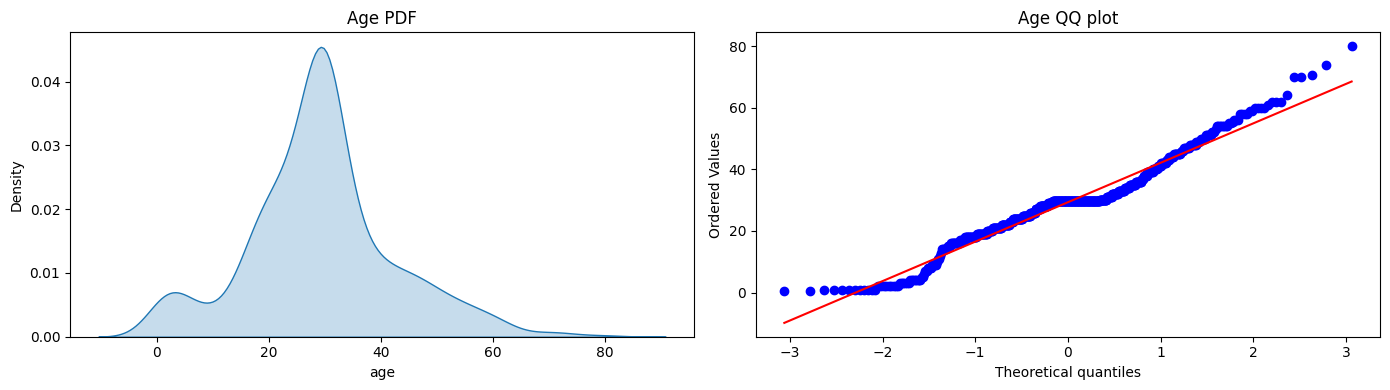

In [80]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,4))

ax1.set_title("Age PDF")
sns.kdeplot(X_train['age'],fill=True,ax= ax1)


stats.probplot(X_train['age'],dist="norm",plot=ax2) # probplot internally calls ax.title(...), which overwrites your title if you set it before the call. 
plt.tight_layout()
ax2.set_title("Age QQ plot")

plt.show()

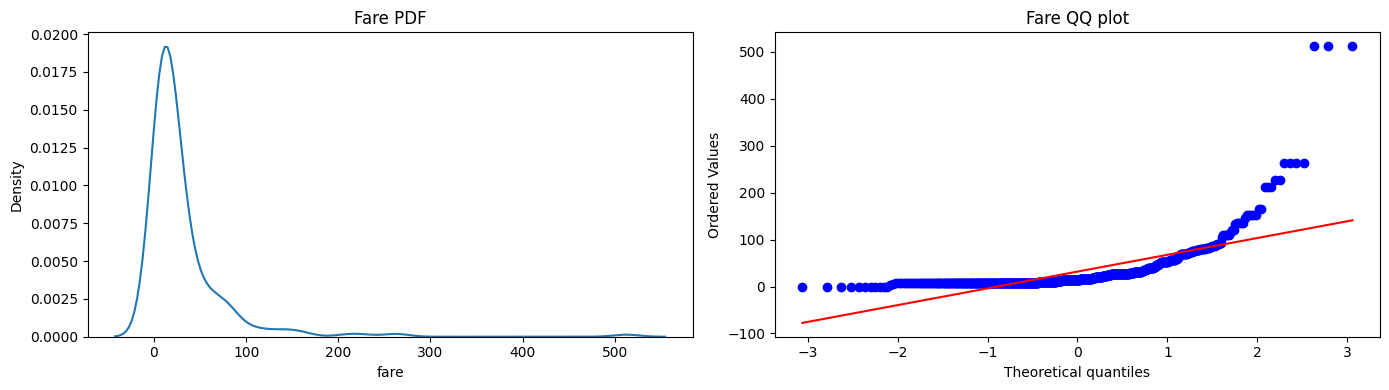

In [81]:
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(14,4))

ax1.set_title("Fare PDF")
sns.kdeplot(X_train['fare'],ax=ax1) 

stats.probplot(X_train['fare'],dist='norm',plot=ax2)
plt.tight_layout()
ax2.set_title("Fare QQ plot")

plt.show()

## Fitting models with out transformation.

In [82]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

clf = DecisionTreeClassifier()
clf2 = LogisticRegression()


In [146]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred1 = clf2.predict(X_test)

print("DT accuracy: ", accuracy_score(y_test,y_pred))
print("LR accuracy: ",accuracy_score(y_test,y_pred1))


DT accuracy:  0.6791044776119403
LR accuracy:  0.6529850746268657


/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


# Applying log transformation and Fitting the models.

In [84]:
from sklearn.preprocessing import FunctionTransformer
tfr = FunctionTransformer(func=np.log1p)

In [85]:
X_train_transformed = tfr.fit_transform(X_train)
X_test_transformed = tfr.transform(X_test)

In [86]:
clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


LogisticRegression()

In [87]:
y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print("DT accuracy: ", accuracy_score(y_test,y_pred))
print("LR accuracy: ",accuracy_score(y_test,y_pred2))


DT accuracy:  0.6753731343283582
LR accuracy:  0.6791044776119403


## we are doing cross validation to see if  transformation actually improved the model.

In [88]:
from sklearn.model_selection import cross_val_score
X_transformed = tfr.fit_transform(df.iloc[:,0:2])
y = df.iloc[:,-1]
clf = DecisionTreeClassifier()
clf2 = LogisticRegression()


print("DT accuracy: ",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("LR accuracy: ",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))


DT accuracy:  0.6565792759051186
LR accuracy:  0.678027465667915


/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

## Let's visualize what happend after transformation. did the distribution changed ?

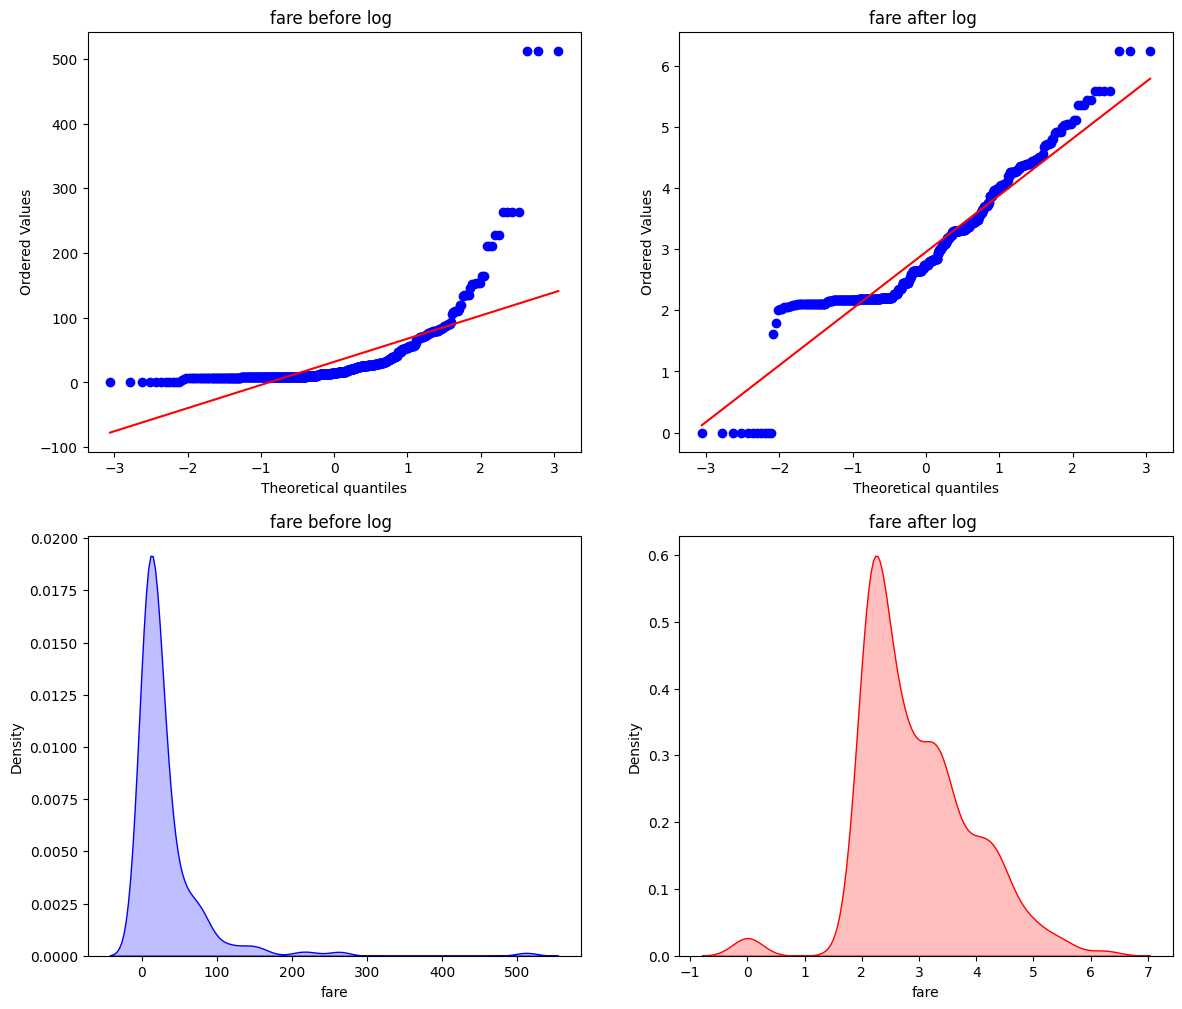

In [89]:
# visualization for 'fare' column
fig,axes = plt.subplots(2,2,figsize=(14,12)) # way to create 2x2 grid of subplots

# visualizing the before and after QQ plots
stats.probplot(X_train['fare'],dist='norm',plot=axes[0,0])
axes[0,0].set_title("fare before log ")

stats.probplot(X_train_transformed['fare'],dist="norm",plot=axes[0,1])
axes[0,1].set_title("fare after log ")

# visualizing the before and after dist plot
sns.kdeplot(X_train['fare'],fill=True,color='blue',ax=axes[1,0])
axes[1,0].set_title("fare before log ")

sns.kdeplot(X_train_transformed['fare'],fill=True,color='red',ax=axes[1,1])
axes[1,1].set_title("fare after log ")


plt.show()


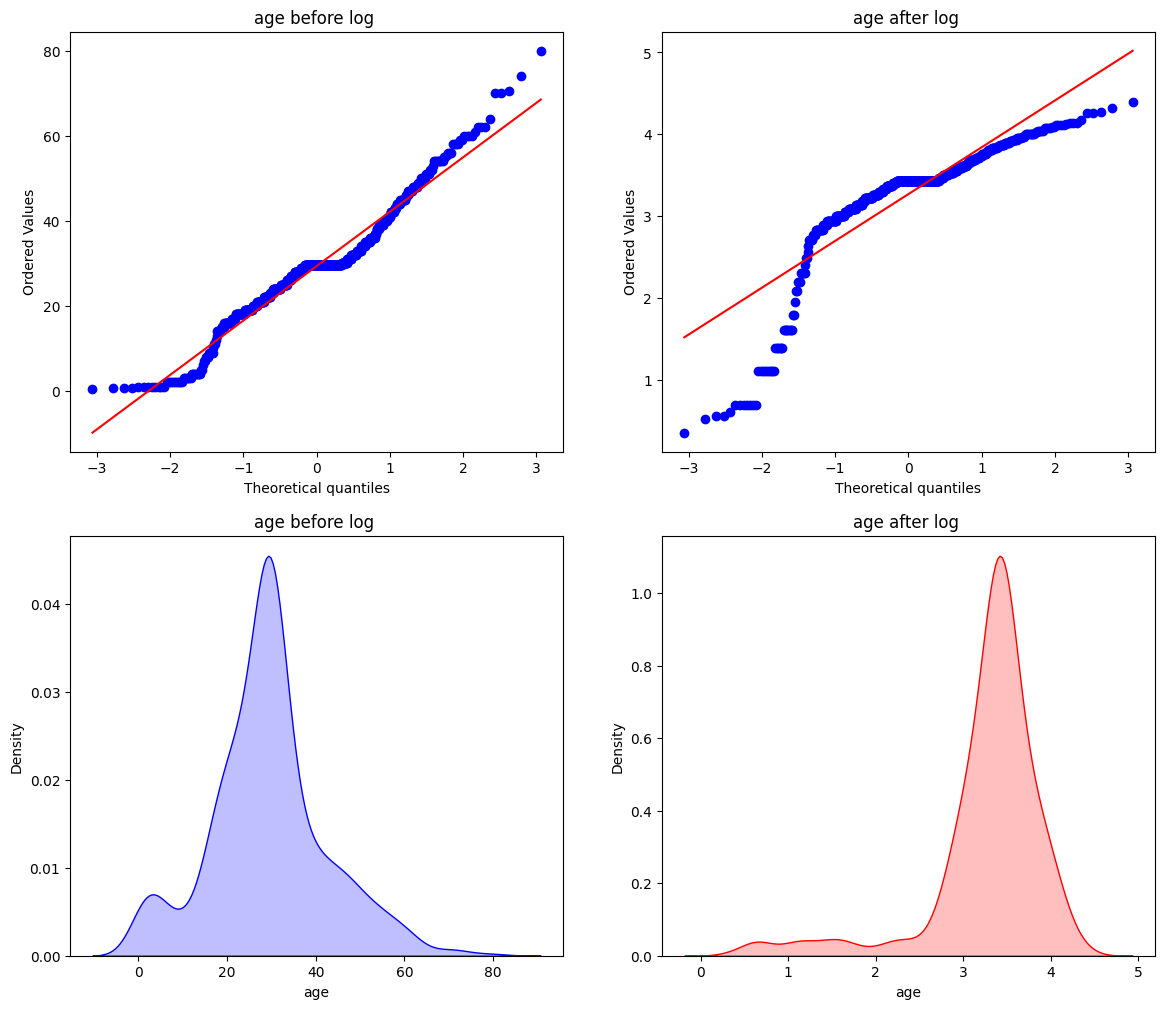

In [90]:
# visulaization for 'age' column 
fig,axes = plt.subplots(2,2,figsize=(14,12))

# visualizing before and after @@ plots
stats.probplot(X_train['age'],dist='norm',plot=axes[0,0])
axes[0,0].set_title("age before log ")

stats.probplot(X_train_transformed['age'],dist="norm",plot=axes[0,1])
axes[0,1].set_title("age after log ")

# visualizing the before and after dist plot
sns.kdeplot(X_train['age'],fill=True,color='blue',ax=axes[1,0])
axes[1,0].set_title("age before log ")

sns.kdeplot(X_train_transformed['age'],fill=True,color='red',ax=axes[1,1])
axes[1,1].set_title("age after log ")


plt.show()



# observation
the 'age' column was already normally distributed but applying log transformation distorted its  normality. thus it is best suggested to try different  transformations and skipping a one if it degrades the existing normal form.

on the other hand, the normality of 'fare' column improved after applying the log transformation.

# so, applying the log transformation to only 'fare' column and observing the model performance.


In [91]:
from sklearn.compose import ColumnTransformer # remember, it takes argument as a list of tuples
tfr2 = ColumnTransformer([
    ('log',FunctionTransformer(func=np.log1p),['fare'])
],remainder='passthrough')

X_train_transformed2 = tfr2.fit_transform(X_train)
X_test_transformed2 = tfr2.transform(X_test)


In [96]:
clf = DecisionTreeClassifier()
clf2 = LogisticRegression()


clf.fit(X_train_transformed2,y_train)
clf2.fit(X_train_transformed2,y_train)

y_pred3 = clf.predict(X_test_transformed2)
y_pred4 = clf2.predict(X_test_transformed2)

print("DT accuracy: ",accuracy_score(y_test,y_pred3))
print("LR accuracy: ",accuracy_score(y_test,y_pred4))


DT accuracy:  0.6791044776119403
LR accuracy:  0.664179104477612


/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept


In [97]:
# preform cross validation again.
X_transformed2 = tfr2.fit_transform(df.iloc[:,0:2])
y = df.iloc[:,-1]

print("DT accuracy: ",np.mean(cross_val_score(clf,X_transformed2,y,scoring='accuracy',cv=10)))
print("LR accuracy: ",np.mean(cross_val_score(clf2,X_transformed2,y,scoring='accuracy',cv=10)))

DT accuracy:  0.6588264669163546
LR accuracy:  0.6712609238451936


/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

# observation
thus it proves that even if we only transform 'fare' column, the performance of the model improves higlighting the
thoutfulness and need of testing with different mathematical transformations and and checking improvement over  different columns before finializing  a model.

# we can also apply custom transformations to see what works.


In [138]:
def apply_transform(transform):
    X = df.iloc[:,0:2]
    y = df.iloc[:,-1]

    tfr = ColumnTransformer([('transformer',FunctionTransformer(func=transform),['fare'])],remainder='passthrough')
    X_transformed_ = tfr.fit_transform(X)

    clf = LogisticRegression()
    
    print("LR accuracy: ",np.mean(cross_val_score(clf,X_transformed_,y,scoring='accuracy',cv=10)))

    fig,axes = plt.subplots(2,2,figsize=(14,12))

    stats.probplot(X['fare'],dist='norm',plot=axes[0,0])
    axes[0,0].set_title("Before applying transformation")

    
    stats.probplot(X_transformed_[:,0],dist='norm',plot=axes[0,1])
    axes[0,1].set_title(f"After applying transformation")

    sns.kdeplot(X['fare'],fill=True,color='blue',ax=axes[1,0])
    axes[1,0].set_title("Before applying transformation")

    sns.kdeplot(X_transformed_[:,0],fill=True,color='red',ax=axes[1,1])
    axes[1,1].set_title("After applying transformation")

    plt.show()
    

/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/prabinthakur/code101/python for ds/ds-env/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

LR accuracy:  0.6611485642946316


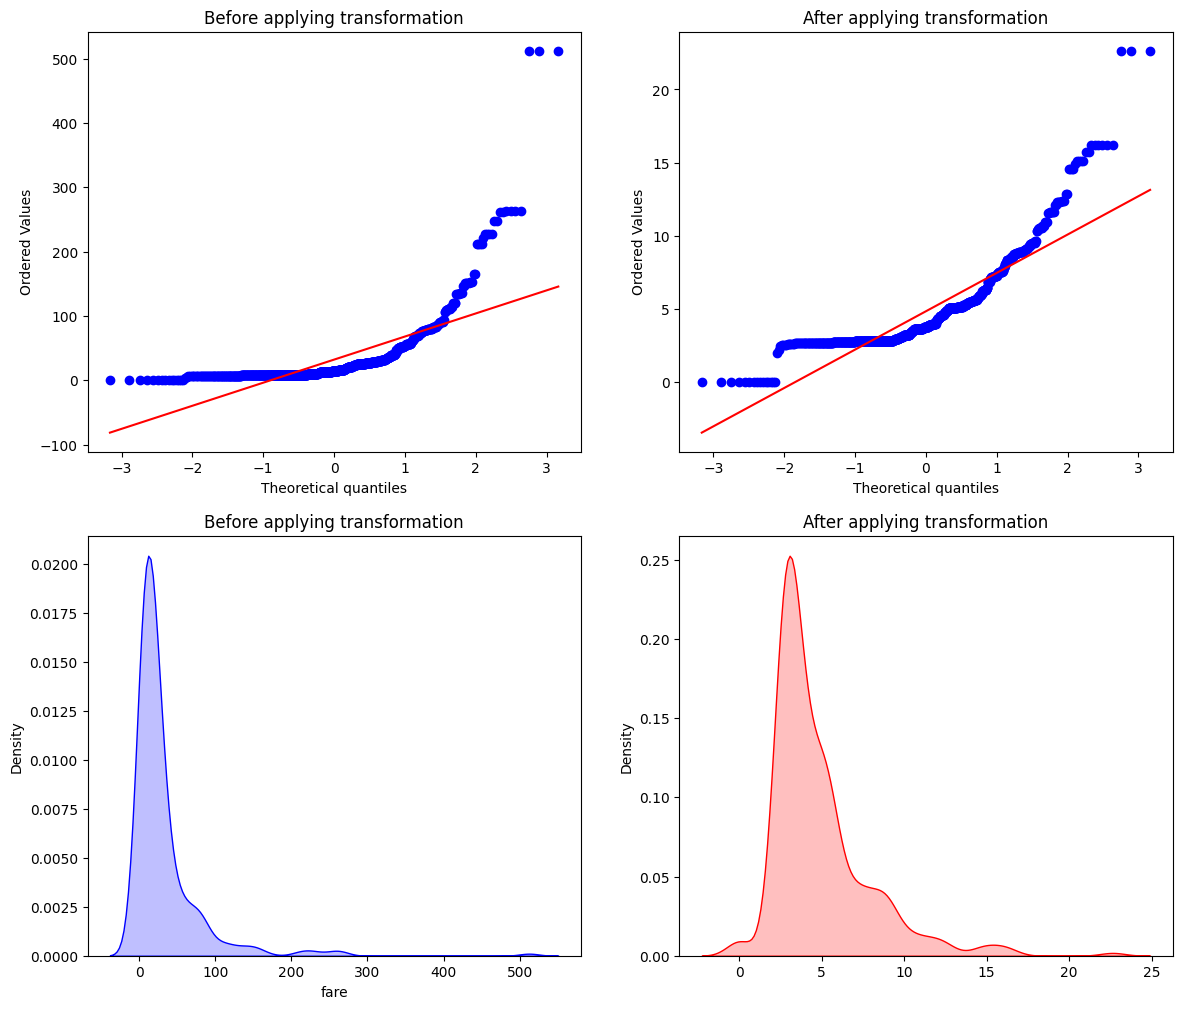

In [145]:
# apply_transform(lambda x: x**(1/3))
apply_transform(lambda x: x**(1/2))
# apply_transform(np.sin)
# apply_transform(np.cos)


In [125]:
tfr = ColumnTransformer([('transformer',FunctionTransformer(np.log1p),['fare'])],remainder='passthrough')
X_transformed_ = tfr.fit_transform(df.iloc[:,0:2])
X_transformed_

array([[ 2.1102132 , 22.        ],
       [ 4.28059312, 38.        ],
       [ 2.18885633, 26.        ],
       ...,
       [ 3.19663022, 29.69911765],
       [ 3.4339872 , 26.        ],
       [ 2.1690537 , 32.        ]])